# Exploratory Data Analysis — PM2.5 in central Paris (2018-2026)

**Question of the project:** can we forecast, the day before, whether fine particles (PM2.5) in central Paris will exceed the WHO daily guideline of **15 µg/m³**?

Before building a model, this notebook answers four questions:
1. **What do the data look like?** Size, period, missing values.
2. **How does PM2.5 behave over time?** Trend, seasons, day of the week.
3. **What drives it?** Weather, other pollutants, the value of the previous day.
4. **What does this imply for the model?** Choice of the variables (features) and of the evaluation.

**Input:** `data/processed/dataset_daily.csv` (one row per day, built by `src/build_dataset.py`).
All charts are also saved in `reports/figures/` for the report and the slides.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..")                                  # the notebook is in notebooks/
DATA = ROOT / "data" / "processed"
FIGURES = ROOT / "reports" / "figures"             # charts reused in the report and slides
FIGURES.mkdir(parents=True, exist_ok=True)

WHO = 15                                           # WHO 2021 daily guideline for PM2.5 (µg/m³)

# One consistent, readable style for every chart
BLUE, ORANGE, GREEN, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#52514e"
plt.rcParams.update({
    "figure.figsize": (10, 4), "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e6e3", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.titlelocation": "left", "axes.titlesize": 12, "axes.labelcolor": GREY,
    "xtick.color": GREY, "ytick.color": GREY, "font.size": 10,
})


def save(name):
    """Save the current chart as PNG (for the report), then display it."""
    plt.tight_layout()
    plt.savefig(FIGURES / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


In [2]:
df = pd.read_csv(DATA / "dataset_daily.csv", parse_dates=["date"])
print(df.shape[0], "days x", df.shape[1], "columns,", df["date"].min().date(), "->", df["date"].max().date())
df.head()

3186 days x 27 columns, 2018-01-01 -> 2026-09-21


,date,co,no2,nox,o3,pm10,pm25,o3_max,source_station,temp_mean_c,temp_min_c,temp_max_c,humidity_mean_pct,pressure_mean_hpa,rain_mm,wind_mean_ms,wind_max_ms,wind_dir_deg,day_of_week,month,is_weekend,is_public_holiday,is_school_holiday,episode_pm10,episode_o3,episode_no2,above_who
0,2018-01-01,NaN,18.39,20.70,61.96,11.26,6.04,70.0,PA04C,8.0,6.4,9.6,79,1005.7,14.5,5.3,9.2,300.0,0,1,0,1,1,0,0,0,0.0
1,2018-01-02,NaN,32.67,40.60,39.29,15.59,8.29,67.0,PA04C,8.7,6.2,13.8,85,1013.0,5.7,4.2,8.5,230.0,1,1,0,0,1,0,0,0,0.0
2,2018-01-03,NaN,20.21,23.08,60.71,15.73,9.17,77.0,PA04C,9.9,6.9,11.6,75,1006.1,11.0,6.1,12.5,310.0,2,1,0,0,1,0,0,0,0.0
3,2018-01-04,NaN,29.79,36.01,40.67,9.79,6.58,59.0,PA04C,11.6,8.2,14.7,85,1002.3,8.7,4.9,9.2,260.0,3,1,0,0,1,0,0,0,0.0
4,2018-01-05,NaN,41.46,49.18,42.87,14.44,NaN,76.0,NaN,8.7,7.9,10.9,87,1001.3,0.6,3.0,6.9,220.0,4,1,0,0,1,0,0,0,NaN


## 1. Missing values

The table is built on a **complete calendar**: a day without a measurement is kept, with an empty value (NaN). This makes the gaps visible instead of hiding them.

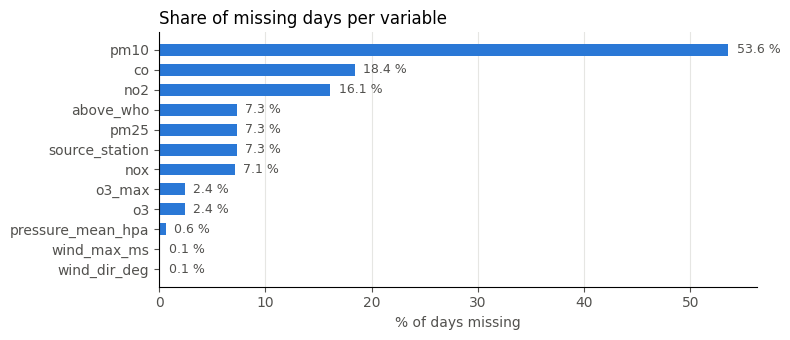

In [3]:
missing = (df.isna().mean() * 100).round(1)
missing = missing[missing > 0].sort_values()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(missing.index, missing.values, color=BLUE, height=0.6)
for y, v in enumerate(missing.values):
    ax.text(v + 0.8, y, f"{v:.1f} %", va="center", color=GREY, fontsize=9)
ax.set_title("Share of missing days per variable")
ax.set_xlabel("% of days missing")
ax.grid(axis="y", visible=False)
save("01_missing_values")

**Reading:**
- **PM2.5 (the target) is missing on 7 % of days**: station breakdowns and the gap when PA04C was replaced by PA01H in 2019. These days cannot be used to train or evaluate the model, but they are **not filled in**: inventing a target would bias the evaluation.
- **PM10 is missing on more than half of the days** (no PM10 at the target station from 2023) and **CO on 18 %**: these two columns will not be used by the model.
- **NO2 is missing on 16 %** (no 2021 file). **NOx**, which contains NO2 and is missing on only 7 %, will replace it.
- The **weather is almost complete** (a handful of days without pressure or wind).

## 2. How does PM2.5 evolve over time?

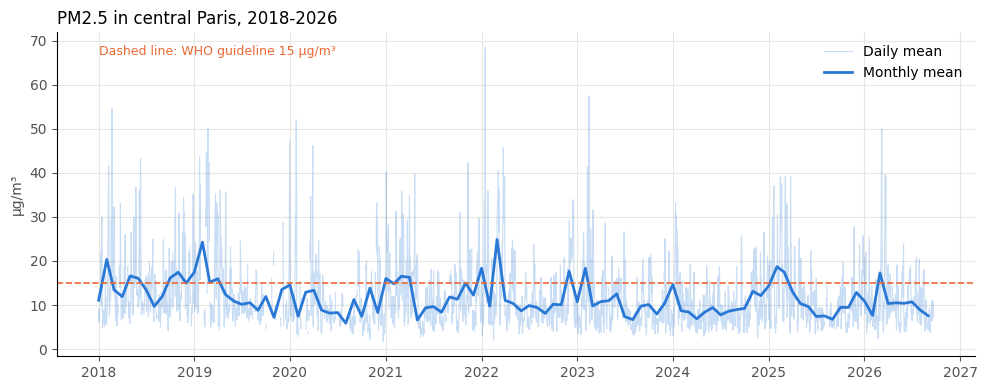

In [4]:
pm = df.set_index("date")["pm25"]
monthly = pm.resample("MS").mean()

fig, ax = plt.subplots()
ax.plot(pm.index, pm.values, color=BLUE, alpha=0.25, linewidth=0.8, label="Daily mean")
ax.plot(monthly.index, monthly.values, color=BLUE, linewidth=2, label="Monthly mean")
ax.axhline(WHO, color=ORANGE, linestyle="--", linewidth=1.2)
ax.text(pm.index.min(), 66, "Dashed line: WHO guideline 15 µg/m³", ha="left", va="bottom", color=ORANGE, fontsize=9)
ax.set_title("PM2.5 in central Paris, 2018-2026")
ax.set_ylabel("µg/m³")
ax.legend(frameon=False, loc="upper right")
save("02_pm25_time_series")

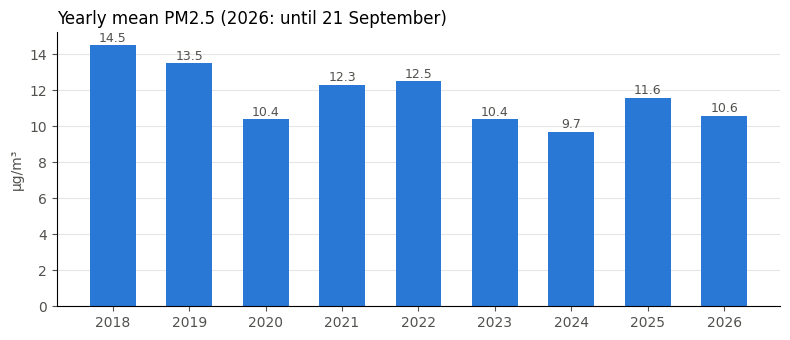

,days_measured,mean_pm25,days_above_who,pct_days_above_who
date,,,,
2018,338,14.5,115.0,34.0
2019,273,13.5,73.0,26.7
2020,302,10.4,49.0,16.2
2021,355,12.3,98.0,27.6
2022,361,12.5,94.0,26.0
2023,363,10.4,66.0,18.2
2024,362,9.7,51.0,14.1
2025,340,11.6,70.0,20.6
2026,261,10.6,42.0,16.1


In [5]:
yearly = df.groupby(df["date"].dt.year).agg(
    days_measured=("pm25", "count"),
    mean_pm25=("pm25", "mean"),
    days_above_who=("above_who", "sum"),
)
yearly["pct_days_above_who"] = (100 * yearly["days_above_who"] / yearly["days_measured"]).round(1)
yearly["mean_pm25"] = yearly["mean_pm25"].round(1)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(yearly.index.astype(str), yearly["mean_pm25"], color=BLUE, width=0.6)
for x, v in enumerate(yearly["mean_pm25"]):
    ax.text(x, v + 0.2, f"{v}", ha="center", color=GREY, fontsize=9)
ax.set_title("Yearly mean PM2.5 (2026: until 21 September)")
ax.set_ylabel("µg/m³")
ax.grid(axis="x", visible=False)
save("03_pm25_yearly")
yearly

**Reading:**
- **Clear downward trend**: from about 14.5 µg/m³ in 2018 to about 10 µg/m³ in 2024. It is consistent with the general decrease of emissions in Paris (vehicle fleet, heating).
- **2020** is low (lockdown), **2021-2022** go up again.
- Caution: in 2018-2019 the series comes from another station (PA04C). Part of the difference may come from the change of station.
- Even at 10 µg/m³ on average, **15 to 30 % of days still exceed the WHO guideline**: the problem is the **peaks**, not the average. This is why the model focuses on exceedance days.

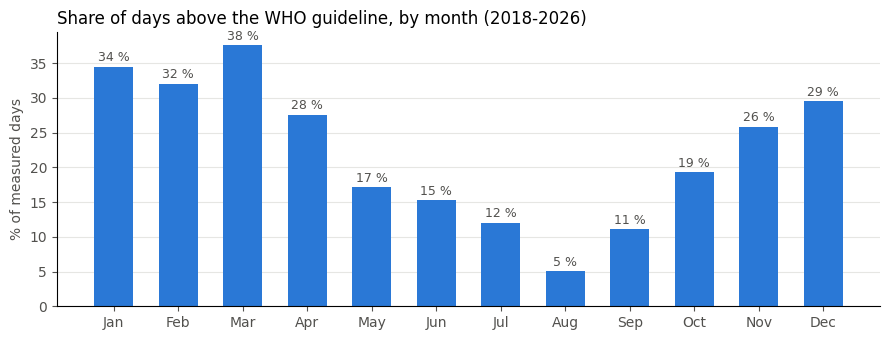

,mean_pm25,pct_above_who
month,,
1,14.2,34.5
2,14.5,32.0
3,15.1,37.5
4,12.2,27.5
5,10.6,17.2
6,10.6,15.2
7,9.5,12.0
8,8.5,5.0
9,9.6,11.1


In [6]:
by_month = df.groupby("month").agg(mean_pm25=("pm25", "mean"), pct_above_who=("above_who", "mean"))
by_month["pct_above_who"] *= 100
months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

fig, ax = plt.subplots(figsize=(9, 3.5))
bars = ax.bar(months, by_month["pct_above_who"], color=BLUE, width=0.6)
for x, v in enumerate(by_month["pct_above_who"]):
    ax.text(x, v + 0.8, f"{v:.0f} %", ha="center", color=GREY, fontsize=9)
ax.set_title("Share of days above the WHO guideline, by month (2018-2026)")
ax.set_ylabel("% of measured days")
ax.grid(axis="x", visible=False)
save("04_seasonality")
by_month.round(1)

**Reading: a strong seasonality.** January to March concentrate the exceedances (around a third of the days), summer almost none. Two known mechanisms:
- **winter**: wood heating emits particles, and cold, calm weather with temperature inversions traps them near the ground;
- **early spring (March)**: fertiliser spreading releases ammonia, which forms "secondary" particles (ammonium nitrate) with traffic pollution.

For the model: **the month is a useful variable**.

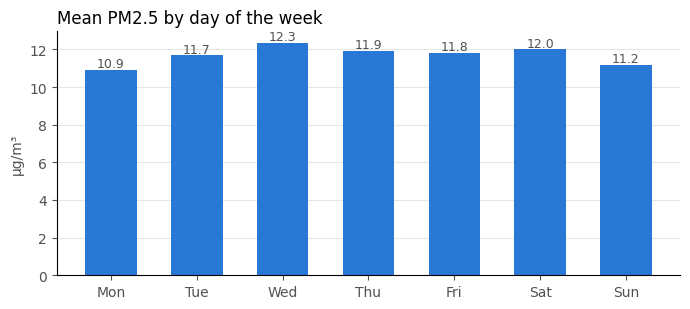

In [7]:
days = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
by_day = df.groupby("day_of_week")["pm25"].mean()

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(days, by_day.values, color=BLUE, width=0.6)
for x, v in enumerate(by_day.values):
    ax.text(x, v + 0.15, f"{v:.1f}", ha="center", color=GREY, fontsize=9)
ax.set_title("Mean PM2.5 by day of the week")
ax.set_ylabel("µg/m³")
ax.grid(axis="x", visible=False)
save("05_day_of_week")

**Reading:** the differences between days are **small** (about 1 µg/m³). Unlike NO2, which comes mostly from traffic and drops at weekends, PM2.5 depends more on weather and on sources that do not stop at weekends (heating, particles coming from outside Paris). The day of the week is kept in the model, but little is expected from it.

## 3. What drives PM2.5?

### 3.1 Correlation with the other variables

The correlation coefficient (Pearson, between −1 and +1) measures how much two variables vary **together, in a straight line**. It does not prove a cause, and it misses non-linear relationships, but it is a good first filter.

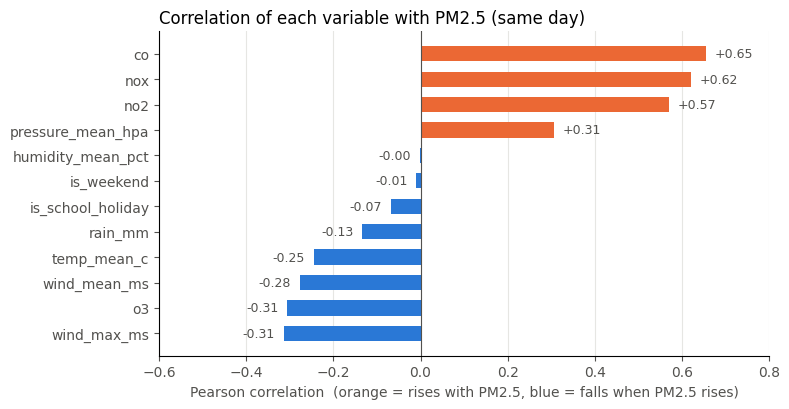

wind_max_ms         -0.31
o3                  -0.31
wind_mean_ms        -0.28
temp_mean_c         -0.25
rain_mm             -0.13
is_school_holiday   -0.07
is_weekend          -0.01
humidity_mean_pct   -0.00
pressure_mean_hpa    0.31
no2                  0.57
nox                  0.62
co                   0.65
Name: pm25, dtype: float64

In [8]:
numeric = ["nox", "no2", "o3", "co", "temp_mean_c", "humidity_mean_pct", "pressure_mean_hpa",
           "rain_mm", "wind_mean_ms", "wind_max_ms", "is_weekend", "is_school_holiday"]
corr = df[numeric + ["pm25"]].corr()["pm25"].drop("pm25").sort_values()

fig, ax = plt.subplots(figsize=(8, 4.2))
colors = [ORANGE if v > 0 else BLUE for v in corr.values]
ax.barh(corr.index, corr.values, color=colors, height=0.6)
ax.axvline(0, color=GREY, linewidth=0.8)
for y, v in enumerate(corr.values):
    ax.text(v + (0.02 if v >= 0 else -0.02), y, f"{v:+.2f}", va="center",
            ha="left" if v >= 0 else "right", color=GREY, fontsize=9)
ax.set_xlim(-0.6, 0.8)
ax.set_title("Correlation of each variable with PM2.5 (same day)")
ax.set_xlabel("Pearson correlation  (orange = rises with PM2.5, blue = falls when PM2.5 rises)")
ax.grid(axis="y", visible=False)
save("06_correlations")
corr.round(2)

**Reading:**
- **Nitrogen oxides (NOx, NO2) and CO rise with PM2.5**: they share the same sources (traffic, heating) and the same weather (air that does not mix).
- **Wind is the main "cleaner"**: the stronger the wind, the lower the PM2.5 (the pollution is dispersed).
- **Temperature** is negatively correlated: cold days are more polluted (heating, stable air).
- **High pressure** (anticyclone, calm and stable weather) goes with more pollution.
- **Ozone (O3)** is negatively correlated: it forms in sunny summer weather, when PM2.5 is low, and in winter it is destroyed by the NO emitted with the particles. It is a marker of the season more than a cause.
- **Rain** has a smaller effect than expected in a straight line: it washes the air on the rainy day, but many dry days are clean too.

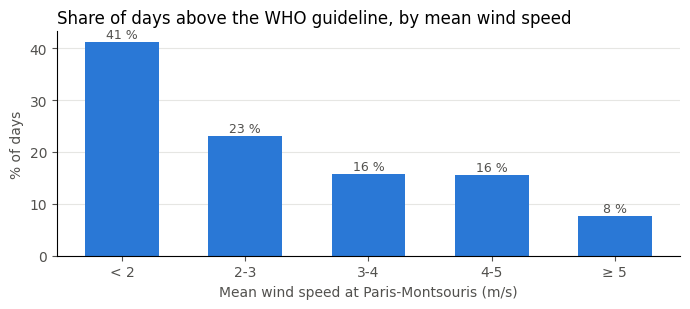

,days,pct_above_who
wind_mean_ms,,
< 2,459,41.2
2-3,1176,23.1
3-4,855,15.8
4-5,334,15.6
≥ 5,130,7.7


In [9]:
wind_classes = pd.cut(df["wind_mean_ms"], bins=[0, 2, 3, 4, 5, 20],
                      labels=["< 2", "2-3", "3-4", "4-5", "≥ 5"])
by_wind = df.groupby(wind_classes, observed=True).agg(days=("pm25", "count"),
                                                      pct_above_who=("above_who", "mean"))
by_wind["pct_above_who"] *= 100

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.bar(by_wind.index.astype(str), by_wind["pct_above_who"], color=BLUE, width=0.6)
for x, v in enumerate(by_wind["pct_above_who"]):
    ax.text(x, v + 0.8, f"{v:.0f} %", ha="center", color=GREY, fontsize=9)
ax.set_title("Share of days above the WHO guideline, by mean wind speed")
ax.set_xlabel("Mean wind speed at Paris-Montsouris (m/s)")
ax.set_ylabel("% of days")
ax.grid(axis="x", visible=False)
save("07_wind_effect")
by_wind.round(1)

**Reading:** the effect of wind is **very strong and non-linear**. Calm days (wind below 2 m/s) exceed the WHO guideline much more often than windy days. A decision-tree model (Random Forest) captures this kind of threshold effect better than a linear model: this is one argument for testing both.

### 3.2 Does today's pollution predict tomorrow's?

This is the key question for a D+1 forecast. Pollution episodes usually last several days (the weather that causes them is persistent).

If today > 15 µg/m³, tomorrow is also above in 65% of cases
If today <= 15 µg/m³, tomorrow is above in only 10% of cases


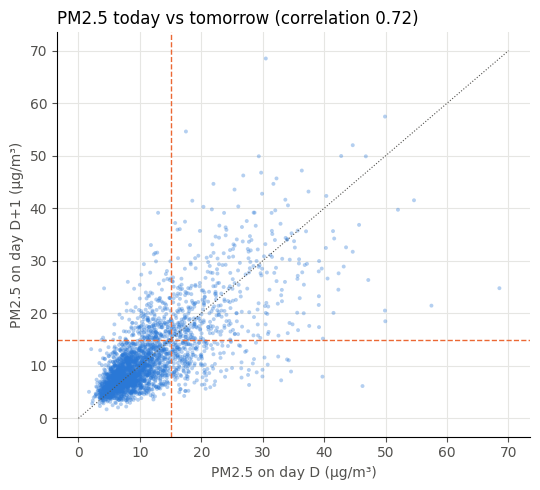

In [10]:
pairs = pd.DataFrame({"today": df["pm25"], "tomorrow": df["pm25"].shift(-1)}).dropna()
r = pairs["today"].corr(pairs["tomorrow"])

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(pairs["today"], pairs["tomorrow"], s=8, alpha=0.35, color=BLUE, edgecolors="none")
ax.plot([0, 70], [0, 70], color=GREY, linewidth=0.8, linestyle=":")
ax.axhline(WHO, color=ORANGE, linestyle="--", linewidth=1)
ax.axvline(WHO, color=ORANGE, linestyle="--", linewidth=1)
ax.set_title(f"PM2.5 today vs tomorrow (correlation {r:.2f})")
ax.set_xlabel("PM2.5 on day D (µg/m³)")
ax.set_ylabel("PM2.5 on day D+1 (µg/m³)")
save("08_persistence")

# How often is "tomorrow above the guideline" when today is above / below?
today_above = pairs["today"] > WHO
tomorrow_above = pairs["tomorrow"] > WHO
print(f"If today > 15 µg/m³, tomorrow is also above in {tomorrow_above[today_above].mean():.0%} of cases")
print(f"If today <= 15 µg/m³, tomorrow is above in only {tomorrow_above[~today_above].mean():.0%} of cases")

**Reading:** today's PM2.5 is **by far the best predictor** of tomorrow's (strong correlation). This has two consequences for the model:
1. the values of the previous days (**lags**: D, D−1, D−2, 7-day mean) will be features;
2. the model must be compared with a **baseline**: "tomorrow = today" (persistence). A model is only useful if it does **better** than this free, obvious rule. The hard cases are the **first day** of an episode and its **end**, which persistence always misses.

### 3.3 Official episodes and our measurements

Mean PM2.5: 35.0 µg/m³ on episode days vs 11.3 on other days
Episode days above the WHO guideline: 98%


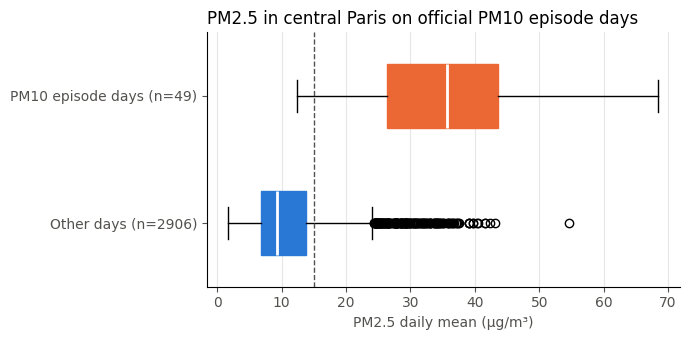

In [11]:
episode = df["episode_pm10"] == 1
groups = [df.loc[~episode, "pm25"].dropna(), df.loc[episode, "pm25"].dropna()]

fig, ax = plt.subplots(figsize=(7, 3.5))
box = ax.boxplot(groups, vert=False, widths=0.5, patch_artist=True,
                 medianprops={"color": "white", "linewidth": 2})
for patch, color in zip(box["boxes"], [BLUE, ORANGE]):
    patch.set_facecolor(color)
    patch.set_edgecolor(color)
ax.set_yticks([1, 2], [f"Other days (n={len(groups[0])})", f"PM10 episode days (n={len(groups[1])})"])
ax.axvline(WHO, color=GREY, linestyle="--", linewidth=1)
ax.set_title("PM2.5 in central Paris on official PM10 episode days")
ax.set_xlabel("PM2.5 daily mean (µg/m³)")
ax.grid(axis="y", visible=False)
save("09_episodes")
print(f"Mean PM2.5: {groups[1].mean():.1f} µg/m³ on episode days vs {groups[0].mean():.1f} on other days")
print(f"Episode days above the WHO guideline: {(groups[1] > WHO).mean():.0%}")

**Reading:** on official particle episode days (information or alert procedures, source: web scraping + Open Data), PM2.5 in central Paris is **much higher**, and almost always above the WHO guideline. Our measurements and the official episodes tell the same story: this **validates the data** from two independent sources.

But official episodes are **rare** (a few dozen days) while WHO exceedances concern **about 1 day in 5**: the WHO guideline is far stricter than the French regulatory thresholds. The official episodes are therefore **not used as a model input** (they are announced on the same day and would "leak" the answer); they serve as an external reference.

### 3.4 Traffic versus background stations (all stations)

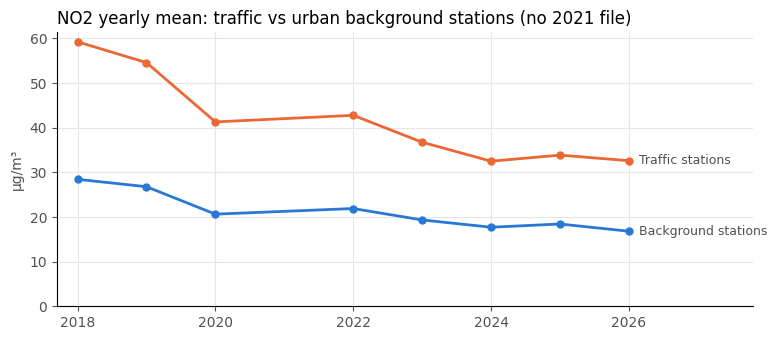

station_type,traffic,urban_background
date,,
2018,59.2,28.4
2019,54.6,26.8
2020,41.3,20.6
2022,42.8,21.9
2023,36.8,19.3
2024,32.5,17.7
2025,33.9,18.4
2026,32.6,16.8


In [12]:
daily = pd.read_csv(DATA / "daily_measurements.csv", parse_dates=["date"])
stations = pd.read_csv(DATA / "stations.csv")
no2 = daily[daily["pollutant_code"] == "NO2"].merge(stations, on="station_code")
no2 = no2[no2["station_type"].isin(["traffic", "urban_background"])]
no2_year = no2.groupby([no2["date"].dt.year, "station_type"])["mean"].mean().unstack()

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(no2_year.index, no2_year["traffic"], color=ORANGE, linewidth=2, marker="o", markersize=5)
ax.plot(no2_year.index, no2_year["urban_background"], color=BLUE, linewidth=2, marker="o", markersize=5)
ax.text(no2_year.index[-1] + 0.15, no2_year["traffic"].iloc[-1], "Traffic stations", color=GREY, va="center", fontsize=9)
ax.text(no2_year.index[-1] + 0.15, no2_year["urban_background"].iloc[-1], "Background stations", color=GREY, va="center", fontsize=9)
ax.set_xlim(no2_year.index.min() - 0.3, no2_year.index.max() + 1.8)
ax.set_ylim(0, None)
ax.set_title("NO2 yearly mean: traffic vs urban background stations (no 2021 file)")
ax.set_ylabel("µg/m³")
save("10_no2_traffic_background")
no2_year.round(1)

**Reading:** next to roads, NO2 is about **twice** the background level, but the gap has been **halved** since 2018 (cleaner vehicles, low-emission zone). This chart is context: the model itself only uses the central-Paris background station.

## 4. Conclusions for the model

| Finding | Consequence for the model |
|---|---|
| PM2.5 today strongly predicts PM2.5 tomorrow | Lag features (D, D−1, D−2, 7-day mean) + a **persistence baseline** to beat |
| Strong seasonality (Jan-Mar) | `month` as a feature |
| Wind, temperature, pressure strongly linked, with threshold effects | Weather features; test a **Random Forest** (non-linear) against a linear model |
| NOx co-varies with PM2.5 | NOx of day D as a feature (NO2, PM10, CO: too many gaps) |
| Clear downward trend over the years | **Time-based split** (train on the past, test on the most recent year), never a random split |
| About 22 % of days exceed the guideline | Moderate imbalance: look at **recall and precision**, not only accuracy |
| Official episodes are rare and announced on the same day | Not a feature (information leak); external reference only |

**Assumption to state clearly:** for day D+1 the model uses the **observed** weather of D+1, as a stand-in for the weather **forecast** that would be available the day before. In real use, forecast errors would lower the performance a little.